# ANÁLISIS DE DATOS

En este notebook, vamos a realizar distintos análisis con los datos ya recolectados y limpios.

In [1]:
# librerías a utilizar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

In [2]:
ruta_unificada_micro = Path('csv_unificado_micro') / 'datos_unificados_micro.csv'
ruta_unificada_metro = Path('csv_unificado_metro') / 'datos_unificados_metro.csv'
ruta_paradero_limpio = Path('data') / 'paraderos_limpios.csv'


# Lectura de archivos
Leemos cada archivo correspondiente:

In [3]:
micro_data = pd.read_csv(ruta_unificada_micro)
micro_data.head(3)

,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,date,X,Y,Hour_minute
0,PB1013,B12,SKDG-90,7520,16,24,2025-10-12 19:01:28.530087,341227.257,6310702.634,19:01
1,PB1013,B33,SKPP-55,2951,8,10,2025-10-12 19:01:28.530094,341227.257,6310702.634,19:01
2,PI725,I10,FLXK-93,2315,7,9,2025-10-12 19:01:30.454781,337333.753,6292318.918,19:01


In [4]:
metro_data = pd.read_csv(ruta_unificada_metro)
metro_data.head(3)

,line_id,station_id,name,status_code,status_description,date,Hora_minuto
0,L1,san-pablo,San Pablo,0,Estación Operativa,2025-10-12 17:07:54.225175,17:07
1,L1,neptuno,Neptuno,0,Estación Operativa,2025-10-12 17:07:54.225191,17:07
2,L1,pajaritos,Pajaritos,0,Estación Operativa,2025-10-12 17:07:54.225193,17:07


In [5]:
recorridos_limpios = pd.read_csv(ruta_paradero_limpio)
recorridos_limpios.head(3)

/tmp/ipykernel_33246/3400555125.py:1: DtypeWarning: Columns (32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  recorridos_limpios = pd.read_csv(ruta_paradero_limpio)


,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,date,Hour_minute,id,codinfra,...,11,12,13,14,15,16,17,18,19,20
0,PB1013,B12,SKDG-90,7520,16,24,2025-10-12 19:01:28.530087,19:01,8983,L-6-39-30-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PB1013,B33,SKPP-55,2951,8,10,2025-10-12 19:01:28.530094,19:01,8983,L-6-39-30-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PI725,I10,FLXK-93,2315,7,9,2025-10-12 19:01:30.454781,19:01,4883,L-13-68-5-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Vemos cómo están dados nuestros datos:
recorridos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312866 entries, 0 to 312865
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   bus_stop_code     312866 non-null  object 
 1   route_id          312866 non-null  object 
 2   bus_id            312866 non-null  object 
 3   meters_distance   312866 non-null  int64  
 4   min_arrival_time  312866 non-null  int64  
 5   max_arrival_time  312866 non-null  int64  
 6   date              312866 non-null  object 
 7   Hour_minute       312866 non-null  object 
 8   id                312866 non-null  int64  
 9   codinfra          312866 non-null  object 
 10  comuna            312866 non-null  object 
 11  nombre_par        312866 non-null  object 
 12  n_servicios       312866 non-null  int64  
 13  lan               312866 non-null  float64
 14  lon               312866 non-null  float64
 15  0                 312866 non-null  object 
 16  1                 28

In [7]:
# Revisamos todos los datos que tenemos en los paraderos limpios:
recorridos_limpios.columns

Index(['bus_stop_code', 'route_id', 'bus_id', 'meters_distance',
       'min_arrival_time', 'max_arrival_time', 'date', 'Hour_minute', 'id',
       'codinfra', 'comuna', 'nombre_par', 'n_servicios', 'lan', 'lon', '0',
       '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20'],
      dtype='object')

Entonces, el máximo de recorridos que pasan por uno de los paraderos contenidos en nuestro DataFrame es de 21.

# ANÁLISIS PARCIAL DE DATOS:
Lo primero que haremos, será crear DataFrames por sector de nuestros datos:

In [8]:
recorrido_poniente = recorridos_limpios[recorridos_limpios['comuna'].isin(['QUINTA NORMAL', 'CERRO NAVIA', 'MAIPÚ', 'CERRILLOS',
                                                     'ESTACIÓN CENTRAL', 'PUDAHUEL', 'RENCA', 'LO PRADO',
                                                     'PADRE HURTADO'])]
recorrido_poniente['comuna'].value_counts()

comuna
MAIPÚ               25519
PUDAHUEL            11039
ESTACIÓN CENTRAL    10029
QUINTA NORMAL        8834
RENCA                8290
CERRO NAVIA          8172
CERRILLOS            7189
LO PRADO             4853
PADRE HURTADO         414
Name: count, dtype: int64

In [9]:
# COMUNAS ORIENTE
recorrido_oriente = recorridos_limpios[recorridos_limpios['comuna'].isin(['PROVIDENCIA', 'ÑUÑOA', 'LA REINA', 'LAS CONDES',
                                                                  'VITACURA', 'LO BARNECHEA', 'PEÑALOLÉN', 'MACUL',
                                                                  'LA FLORIDA', 'PUENTE ALTO'])]
recorrido_oriente['comuna'].value_counts()

comuna
PUENTE ALTO     24293
LAS CONDES      16063
LA FLORIDA      15866
PEÑALOLÉN       11948
ÑUÑOA            9470
PROVIDENCIA      7905
LA REINA         6539
MACUL            6438
VITACURA         4934
LO BARNECHEA     3586
Name: count, dtype: int64

In [10]:
# SECTOR SUR
recorrido_sur = recorridos_limpios[recorridos_limpios['comuna'].isin(['PEDRO AGUIRRE CERDA', 'SAN MIGUEL',
                                                              'SAN JOAQUÍN', 'LO ESPEJO', 'LA CISTERNA',
                                                              'LA GRANJA', 'SAN RAMÓN', 'EL BOSQUE',
                                                              'SAN BERNARDO', 'LA CISTERNA'])]
recorrido_sur['comuna'].value_counts()

comuna
SAN BERNARDO           11720
EL BOSQUE               7536
LA GRANJA               5844
LO ESPEJO               5610
LA CISTERNA             5590
SAN MIGUEL              5245
SAN RAMÓN               4652
PEDRO AGUIRRE CERDA     4515
SAN JOAQUÍN             4243
Name: count, dtype: int64

In [11]:
# SECTOR NORTE
recorrido_norte = recorridos_limpios[recorridos_limpios['comuna'].isin(['CONCHALÍ', 'HUECHURABA', 'INDEPENDENCIA', 'RECOLETA', 'QUILICURA'])]
recorrido_norte['comuna'].value_counts()

comuna
QUILICURA        11112
CONCHALÍ          7033
RECOLETA          6657
HUECHURABA        4863
INDEPENDENCIA     4420
Name: count, dtype: int64

In [12]:
# Revisaremos la mediana de los metros de distancia por sector
mediana_meters_norte = recorrido_norte.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_meters_sur = recorrido_sur.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_meters_oriente = recorrido_oriente.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_meters_poniente = recorrido_poniente.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_oriente_poniente = pd.merge(mediana_meters_oriente, mediana_meters_poniente, on='Hour_minute', how='outer')
mediana_oriente_poniente = mediana_oriente_poniente.set_axis(['Sector Oriente', 'Sector Poniente'], axis= 1)
mediana_norte_sur = pd.merge(mediana_meters_norte, mediana_meters_sur, on='Hour_minute', how='outer')
mediana_norte_sur = mediana_norte_sur.set_axis(['Sector Norte', 'Sector Sur'], axis= 1)
mediana_meters_sector = pd.merge(mediana_norte_sur, mediana_oriente_poniente, on='Hour_minute', how='outer')
mediana_meters_sector.drop(mediana_meters_sector.index[2], inplace=True)
mediana_meters_sector.drop(mediana_meters_sector.index[7], inplace=True)

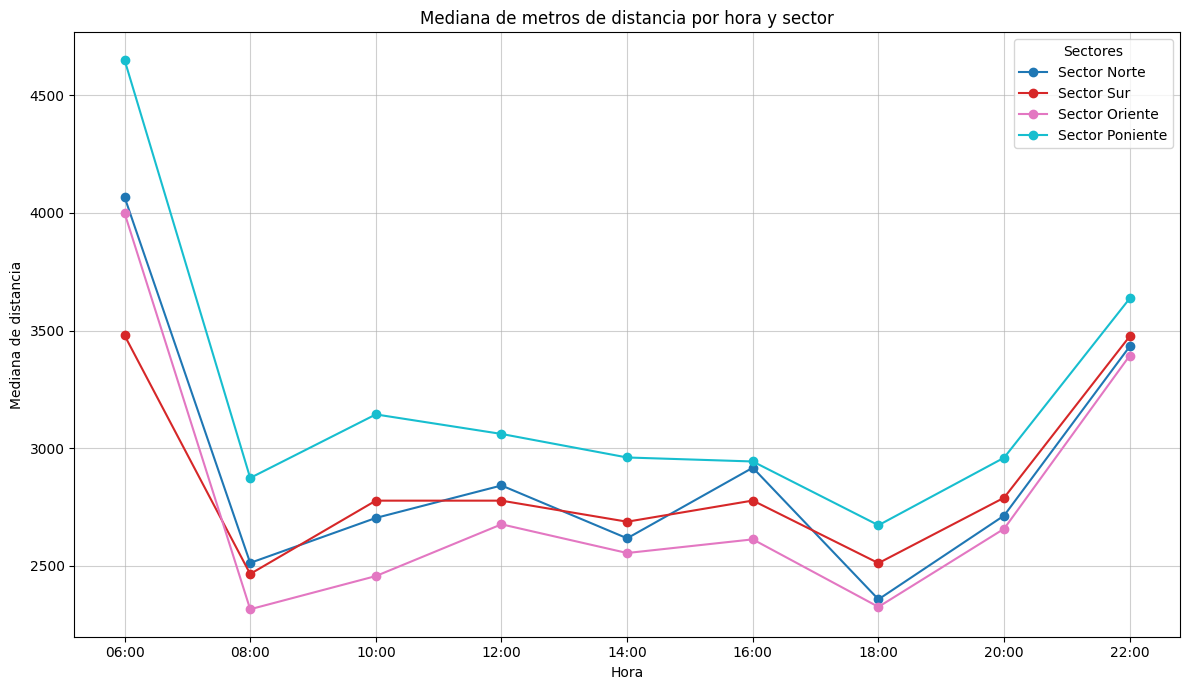

In [13]:
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(mediana_meters_sector.columns):
    plt.plot(mediana_meters_sector.index,
            mediana_meters_sector[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(mediana_meters_sector.columns) - 1)))

plt.title("Mediana de metros de distancia por hora y sector")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

Ahora, según la mediana de los metros de distancia, veremos el mínimo y máximo de distancia por sector (y sus comunas) y la diferencia de estos.

In [14]:
distancia_norte = recorrido_norte.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_norte['DISTANCIA_MIN'] = distancia_norte.min(axis=1)
distancia_norte['DISTANCIA_MAX'] = distancia_norte.max(axis=1)
distancia_norte['RANGO_DESBALANCE'] = distancia_norte.max(axis=1) - distancia_norte.min(axis=1) 
distancia_norte.drop(distancia_norte.index[2], inplace=True)
distancia_norte.drop(distancia_norte.index[7], inplace=True)
distancia_norte.sort_index()

comuna,CONCHALÍ,HUECHURABA,INDEPENDENCIA,QUILICURA,RECOLETA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,
06:00,4052.0,4838.0,3548.5,3873.0,4048.5,3548.5,4838.0,1289.5
08:00,2974.0,3221.5,2270.0,2121.0,2281.0,2121.0,3221.5,1100.5
10:00,3073.5,2766.5,2428.5,2743.0,2398.5,2398.5,3073.5,675.0
12:00,3126.0,3077.5,2537.0,2790.0,2558.0,2537.0,3126.0,589.0
14:00,3046.0,3210.5,2435.0,2397.0,2445.0,2397.0,3210.5,813.5
16:00,3186.0,3122.0,2895.5,2532.0,3002.0,2532.0,3186.0,654.0
18:00,2636.0,2876.0,2354.0,2166.0,2167.0,2166.0,2876.0,710.0
20:00,2924.0,2891.0,3109.0,2180.0,2865.5,2180.0,3109.0,929.0
22:00,3361.0,3735.0,3431.5,3253.5,3680.5,3253.5,3735.0,481.5


In [15]:
distancia_sur = recorrido_sur.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_sur['DISTANCIA_MIN'] = distancia_sur.min(axis=1)
distancia_sur['DISTANCIA_MAX'] = distancia_sur.max(axis=1)
distancia_sur['RANGO_DESBALANCE'] = distancia_sur.max(axis=1) - distancia_sur.min(axis=1) 
distancia_sur.drop(distancia_sur.index[2], inplace=True)
distancia_sur.drop(distancia_sur.index[7], inplace=True)
distancia_sur.sort_index()

comuna,EL BOSQUE,LA CISTERNA,LA GRANJA,LO ESPEJO,PEDRO AGUIRRE CERDA,SAN BERNARDO,SAN JOAQUÍN,SAN MIGUEL,SAN RAMÓN,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,
06:00,2756.5,3051.0,3555.5,3388.0,3653.0,3724.5,3796.0,3947.0,3978.0,2756.5,3978.0,1221.5
08:00,1891.5,2546.0,2449.0,2446.0,3221.0,2361.5,2807.5,2613.0,2445.0,1891.5,3221.0,1329.5
10:00,2470.0,2814.0,2771.5,2787.0,3053.0,2872.0,2673.0,2585.5,2884.5,2470.0,3053.0,583.0
12:00,2500.0,2623.0,2861.0,2888.5,3183.0,2813.0,2908.0,2685.0,2701.5,2500.0,3183.0,683.0
14:00,2131.0,2452.5,2938.0,2672.0,3115.5,2647.0,2795.0,2594.0,2885.0,2131.0,3115.5,984.5
16:00,2434.5,2461.0,2789.5,2923.5,3353.0,2961.0,2867.0,2722.0,2658.0,2434.5,3353.0,918.5
18:00,2222.0,2122.0,2787.5,2798.5,2766.0,2440.5,2861.0,2487.0,2653.5,2122.0,2861.0,739.0
20:00,2279.5,2756.5,3122.5,2828.0,2890.5,2802.0,3240.0,2889.5,2485.5,2279.5,3240.0,960.5
22:00,2749.0,3650.0,3516.0,3841.5,3776.0,3401.0,3874.0,3752.5,3362.0,2749.0,3874.0,1125.0


In [16]:
distancia_oriente = recorrido_oriente.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_oriente['DISTANCIA_MIN'] = distancia_oriente.min(axis=1)
distancia_oriente['DISTANCIA_MAX'] = distancia_oriente.max(axis=1)
distancia_oriente['RANGO_DESBALANCE'] = distancia_oriente.max(axis=1) - distancia_oriente.min(axis=1) 
distancia_oriente.drop(distancia_oriente.index[2], inplace=True)
distancia_oriente.drop(distancia_oriente.index[7], inplace=True)
distancia_oriente.sort_index()

comuna,LA FLORIDA,LA REINA,LAS CONDES,LO BARNECHEA,MACUL,PEÑALOLÉN,PROVIDENCIA,PUENTE ALTO,VITACURA,ÑUÑOA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,,
06:00,3176.0,4619.0,4261.0,4472.0,3930.0,4994.0,4372.0,3434.0,4686.0,4558.0,3176.0,4994.0,1818.0
08:00,2291.5,2219.0,2104.0,2091.0,2724.5,2530.5,1863.0,2362.0,2662.0,2363.0,1863.0,2724.5,861.5
10:00,2545.0,2486.0,2092.5,2421.5,2802.5,2799.0,2058.5,2592.5,2344.0,2355.5,2058.5,2802.5,744.0
12:00,2773.0,2672.0,2763.0,2727.0,2621.0,2799.5,2738.0,2621.5,2571.0,2483.5,2483.5,2799.5,316.0
14:00,2429.0,2631.0,2493.5,2450.0,2729.0,2712.5,2319.0,2536.0,3096.0,2529.0,2319.0,3096.0,777.0
16:00,2534.0,2946.0,2593.0,2521.0,2807.0,2678.5,2467.5,2592.0,3147.0,2481.0,2467.5,3147.0,679.5
18:00,2299.0,2521.0,2103.0,2184.0,2571.5,2578.0,2118.5,2355.0,2408.5,2118.5,2103.0,2578.0,475.0
20:00,2638.5,2973.5,2584.5,2302.0,2825.0,2635.0,2672.0,2494.0,2821.0,2946.0,2302.0,2973.5,671.5
22:00,3167.0,3950.0,3815.5,3793.5,3451.0,3409.0,3987.5,2957.5,3283.0,3520.5,2957.5,3987.5,1030.0


In [17]:
distancia_poniente = recorrido_poniente.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_poniente['DISTANCIA_MIN'] = distancia_poniente.min(axis=1)
distancia_poniente['DISTANCIA_MAX'] = distancia_poniente.max(axis=1)
distancia_poniente.drop(distancia_poniente.index[2], inplace=True)
distancia_poniente.drop(distancia_poniente.index[7], inplace=True)
distancia_poniente['RANGO_DESBALANCE'] = distancia_poniente.max(axis=1) - distancia_poniente.min(axis=1) 
distancia_poniente.sort_index()

comuna,CERRILLOS,CERRO NAVIA,ESTACIÓN CENTRAL,LO PRADO,MAIPÚ,PADRE HURTADO,PUDAHUEL,QUINTA NORMAL,RENCA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,
06:00,4628.0,6441.0,4489.0,4952.0,4524.0,1974.0,4778.0,4530.5,4360.0,1974.0,6441.0,4467.0
08:00,3657.5,2923.0,2777.5,2690.0,2592.0,1433.0,2908.0,3381.5,2904.5,1433.0,3657.5,2224.5
10:00,3922.0,3017.0,3096.0,3075.0,3002.0,1510.0,3507.0,3078.0,3014.0,1510.0,3922.0,2412.0
12:00,3732.5,3089.0,2994.0,2954.0,2933.0,1634.0,3224.0,3205.0,2918.0,1634.0,3732.5,2098.5
14:00,3732.0,2979.5,2573.0,3029.0,2703.0,958.5,3270.5,2965.5,3129.0,958.5,3732.0,2773.5
16:00,3755.5,2800.0,2921.0,2844.0,2722.5,1198.0,3163.0,2948.0,3313.0,1198.0,3755.5,2557.5
18:00,3209.5,2686.0,2503.5,2222.0,2757.0,1316.0,2425.0,2760.0,2887.0,1316.0,3209.5,1893.5
20:00,3886.5,2799.0,3039.0,3046.0,2878.0,1579.0,2683.0,3153.5,3010.0,1579.0,3886.5,2307.5
22:00,4255.0,3248.0,3729.0,3629.0,3427.5,2316.5,3594.0,4253.0,3776.0,2316.5,4255.0,1938.5


In [18]:
mediana_tiempo_norte = recorrido_norte.groupby(by='Hour_minute').agg({'max_arrival_time': 'median'})
mediana_tiempo_sur = recorrido_sur.groupby(by='Hour_minute').agg({'max_arrival_time': 'median'})
mediana_tiempo_oriente = recorrido_oriente.groupby(by='Hour_minute').agg({'max_arrival_time': 'median'})
mediana_tiempo_poniente = recorrido_poniente.groupby(by='Hour_minute').agg({'max_arrival_time': 'median'})
mediana_oriente_poniente = pd.merge(mediana_tiempo_oriente, mediana_tiempo_poniente, on='Hour_minute', how='outer')
mediana_oriente_poniente = mediana_oriente_poniente.set_axis(['Sector Oriente', 'Sector Poniente'], axis= 1)
mediana_norte_sur = pd.merge(mediana_tiempo_norte, mediana_tiempo_sur, on='Hour_minute', how='outer')
mediana_norte_sur = mediana_norte_sur.set_axis(['Sector Norte', 'Sector Sur'], axis= 1)
mediana_por_sector = pd.merge(mediana_norte_sur, mediana_oriente_poniente, on='Hour_minute', how='outer')
mediana_por_sector.drop(mediana_por_sector.index[2], inplace=True)
mediana_por_sector.drop(mediana_por_sector.index[7], inplace=True)

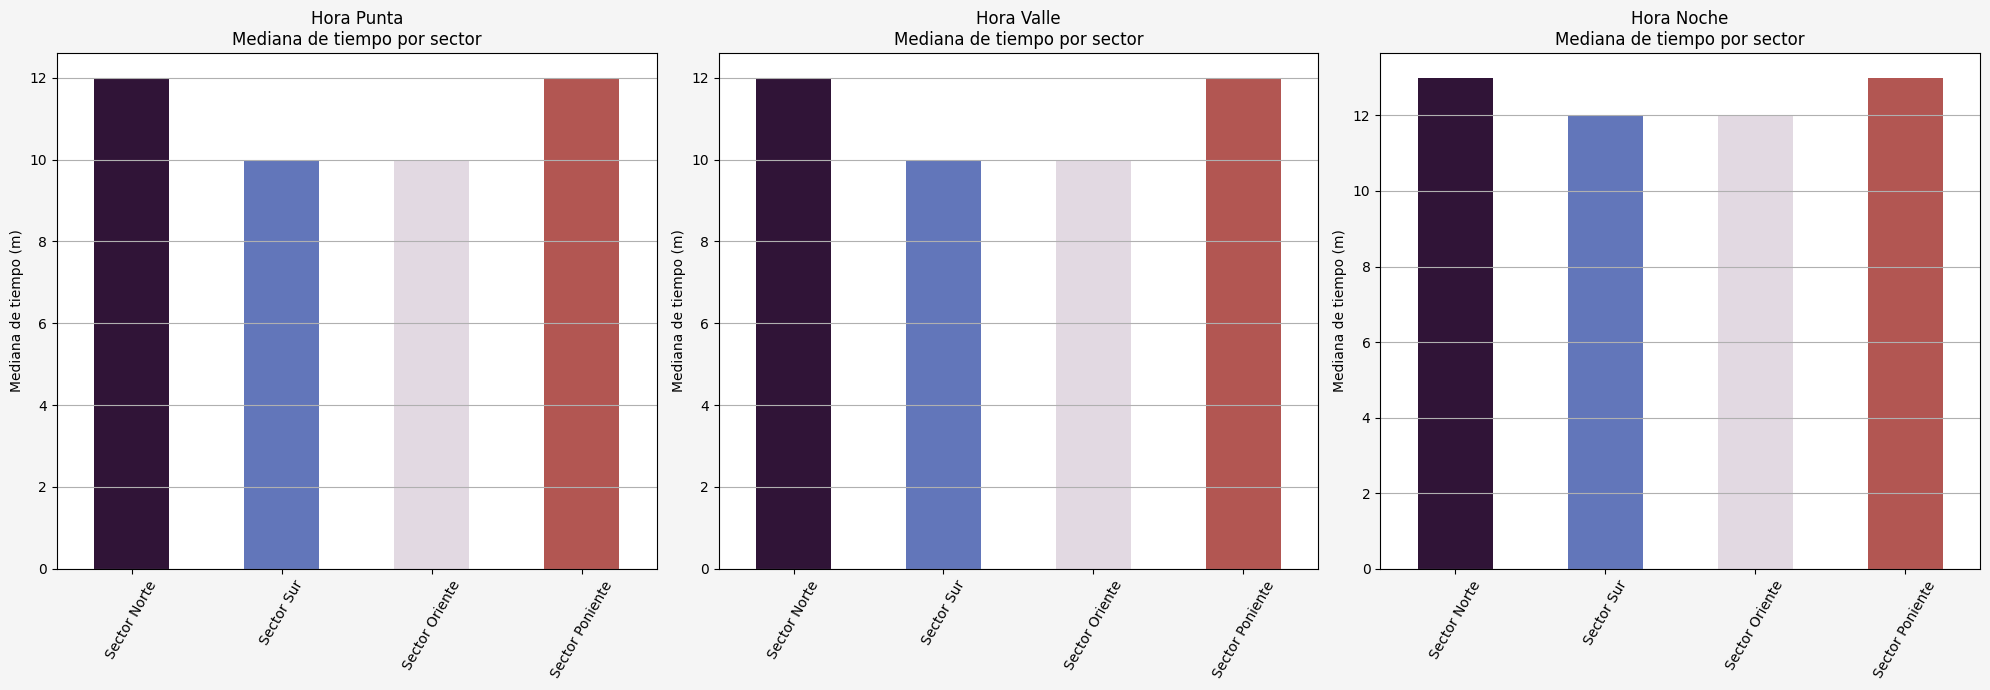

In [19]:
resultados_por_sector = {
    'Hora Punta': mediana_por_sector.loc['08:00'],
    'Hora Valle': mediana_por_sector.loc['14:00'],
    'Hora Noche': mediana_por_sector.loc['18:00']
}

# Creamos figura
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#f5f5f5')

# Colormap continuo para variar colores entre sectores
cmap = plt.colormaps['twilight_shifted']

for i, (hora, mediana_hora) in enumerate(resultados_por_sector.items()):
    sector = mediana_hora.index
    minutos = mediana_hora.values
    # Graficamos barras por sector
    mediana_hora.plot(
        kind='bar', 
        ax=axes[i], 
        color = [cmap(v / len(minutos)) for v in range(len(minutos))]
    )
    
    axes[i].set_title(f'{hora}\nMediana de tiempo por sector')
    axes[i].set_ylabel('Mediana de tiempo (m)')
    axes[i].tick_params(axis='x', rotation=60)
    axes[i].grid(axis='y', alpha=1)

plt.tight_layout()
plt.show()

Revisemos cuáles son los recorridos que más aparecen en nuestro DataFrame por sector, y cómo suele ser su mediana de datos según la hora:

In [20]:
# RECORRIDOS FRECUENTES NORTE
recorrido_norte['route_id'].value_counts().head(5)
b21_rec = recorrido_norte[recorrido_norte['route_id'] == 'B21']
b12_rec = recorrido_norte[recorrido_norte['route_id'] == 'B12']
b11_rec = recorrido_norte[recorrido_norte['route_id'] == 'B11']
b06_rec = recorrido_norte[recorrido_norte['route_id'] == 'B06']
rec_425 = recorrido_norte[recorrido_norte['route_id'] == '425']
b21_meters = b21_rec.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
b12_meters = b12_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
b11_meters = b11_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
b06_meters = b06_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_425 = rec_425.groupby('Hour_minute').agg({'meters_distance': 'median'})
b21_meters.rename(columns={'meters_distance':'B21'}, inplace=True)
b12_meters.rename(columns={'meters_distance':'B12'}, inplace=True)
b11_meters.rename(columns={'meters_distance':'B11'}, inplace=True)
b06_meters.rename(columns={'meters_distance':'B06'}, inplace=True)
meters_425.rename(columns={'meters_distance':'425'}, inplace=True)
# Concatenamos horizontalmente
meters_recorrido_norte = pd.concat([b21_meters, b12_meters, b11_meters, b06_meters, meters_425], axis=1)
meters_recorrido_norte.drop(meters_recorrido_norte.index[2], inplace=True)
meters_recorrido_norte.drop(meters_recorrido_norte.index[7], inplace=True)


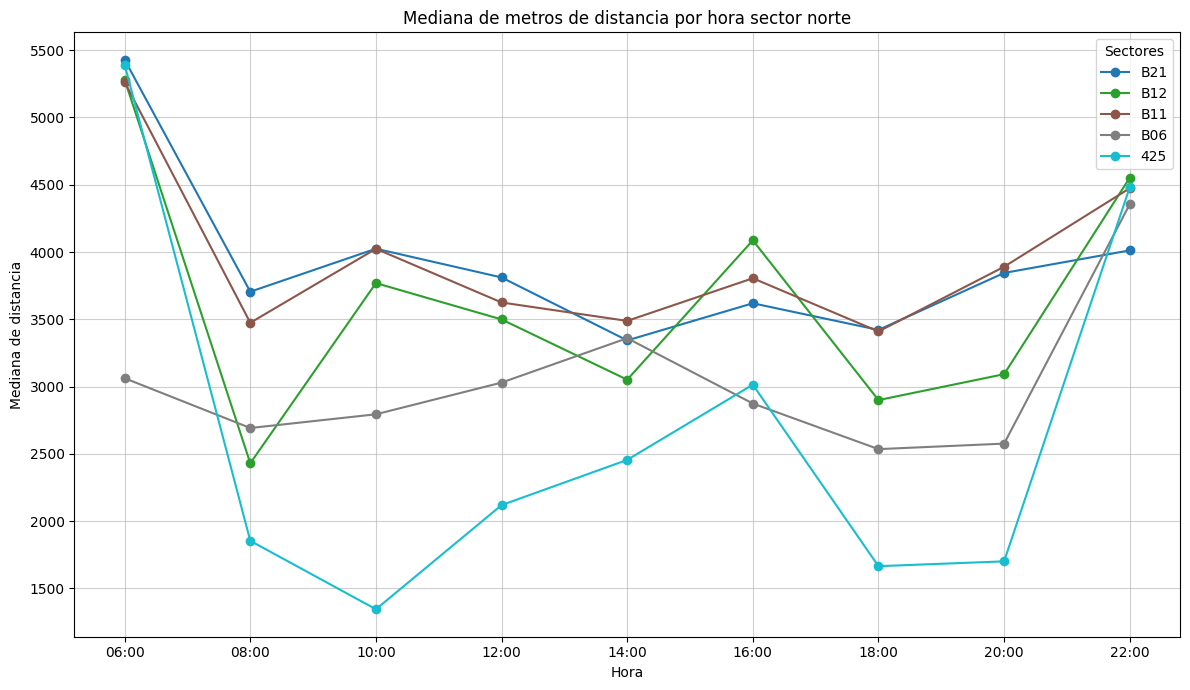

In [21]:
# CREAMOS GRÁFICO PARA RECORRIDOS DEL SECTOR NORTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_norte.columns):
    plt.plot(meters_recorrido_norte.index,
            meters_recorrido_norte[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_norte.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector norte")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [22]:
# RECORRIDOS FRECUENTES SUR
recorrido_sur['route_id'].value_counts().head(5)
g09_rec = recorrido_sur[recorrido_sur['route_id'] =='G09']
rec_211 = recorrido_sur[recorrido_sur['route_id'] == '211']
g07_rec = recorrido_sur[recorrido_sur['route_id'] == 'G07']
h24_rec = recorrido_sur[recorrido_sur['route_id'] == 'H24']
g08v_rec = recorrido_sur[recorrido_sur['route_id'] == 'g08v']

g09_meters = g09_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_211 = rec_211.groupby('Hour_minute').agg({'meters_distance': 'median'})
g07_meters = g07_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
h24_meters = h24_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
g08v_meters = g08v_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
g09_meters.rename(columns={'meters_distance':'G09'}, inplace=True)
meters_211.rename(columns={'meters_distance':'211'}, inplace=True)
g07_meters.rename(columns={'meters_distance':'G07'}, inplace=True)
h24_meters.rename(columns={'meters_distance':'H24'}, inplace=True)
g08v_meters.rename(columns={'meters_distance':'G08V'}, inplace=True)
meters_recorrido_sur = pd.concat([g09_meters, meters_211, g07_meters, h24_meters, g08v_meters], axis=1)
meters_recorrido_sur.drop(meters_recorrido_sur.index[2], inplace=True)
meters_recorrido_sur.drop(meters_recorrido_sur.index[7], inplace=True)

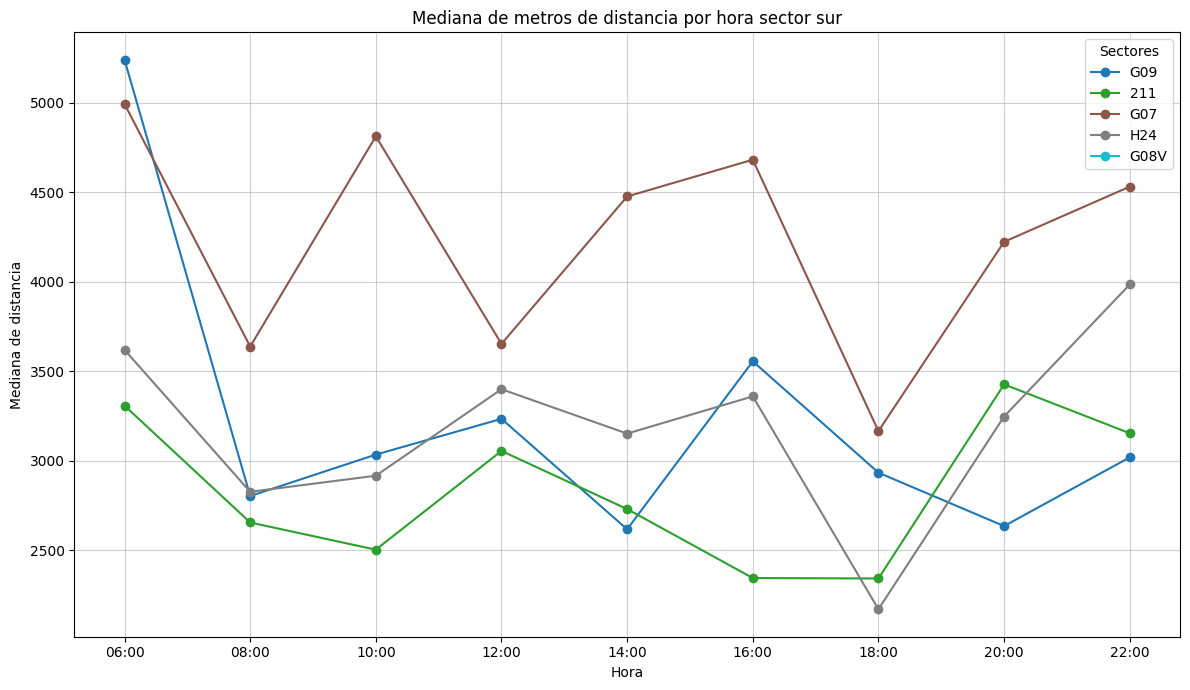

In [23]:
# GRAFICAMOS PARA SECTOR SUR
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_sur.columns):
    plt.plot(meters_recorrido_sur.index,
            meters_recorrido_sur[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_sur.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector sur")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [24]:
# RECORRIDOS FRECUENTES PONIENTE
recorrido_poniente['route_id'].value_counts().head(5)
rec_109 = recorrido_poniente[recorrido_poniente['route_id'] == '109']
i04_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'I04']
i03_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'I03']
rec_110 = recorrido_poniente[recorrido_poniente['route_id'] == '110']
i10_rec = recorrido_poniente[recorrido_poniente['route_id'] == 'i10']
meters_109 = rec_109.groupby('Hour_minute').agg({'meters_distance': 'median'})
i04_meters = i04_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
i03_meters = i03_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_110 = rec_110.groupby('Hour_minute').agg({'meters_distance': 'median'})
i10_meters = i10_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_109.rename(columns={'meters_distance':'109'}, inplace=True)
i04_meters.rename(columns={'meters_distance':'I04'}, inplace=True)
i03_meters.rename(columns={'meters_distance':'I03'}, inplace=True)
meters_110.rename(columns={'meters_distance':'110'}, inplace=True)
i10_meters.rename(columns={'meters_distance':'I10'}, inplace=True)
meters_recorrido_poniente = pd.concat([meters_109, i04_meters, i03_meters, meters_110, i10_meters], axis=1)
meters_recorrido_poniente.drop(meters_recorrido_poniente.index[2], inplace=True)
meters_recorrido_poniente.drop(meters_recorrido_poniente.index[7], inplace=True)

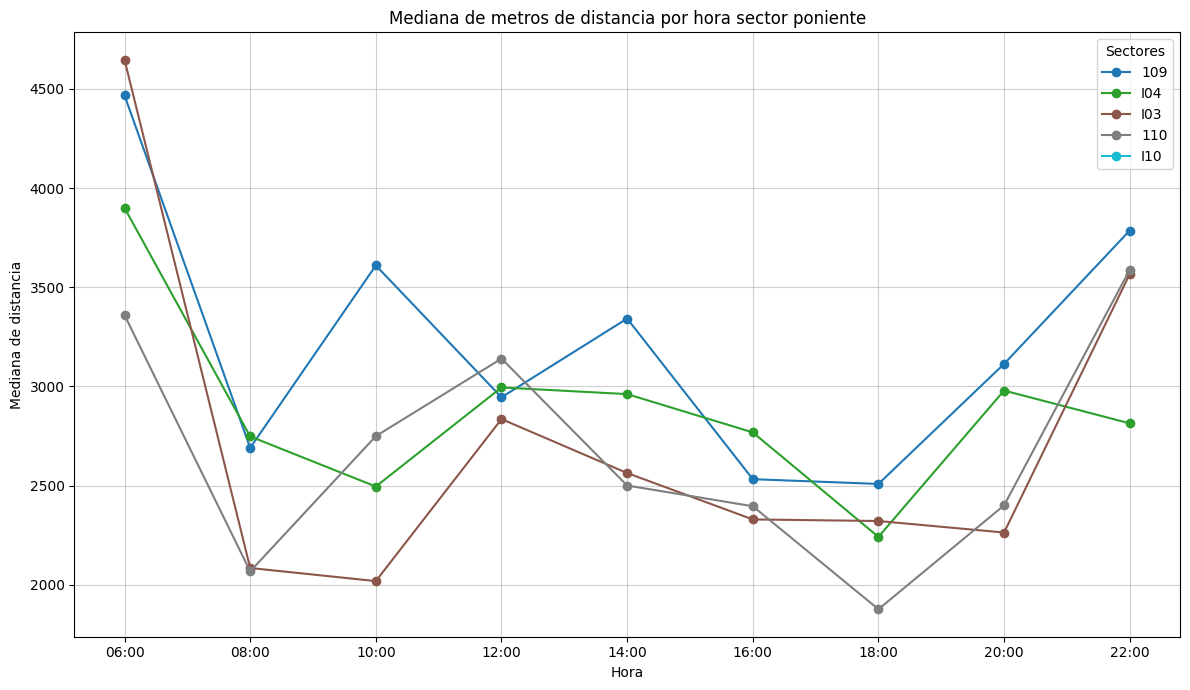

In [25]:
# GRAFICAMOS PARA SECTOR PONIENTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_poniente.columns):
    plt.plot(meters_recorrido_poniente.index,
            meters_recorrido_poniente[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_poniente.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector poniente")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [26]:
# RECORRIDOS FRECUENTES ORIENTE
recorrido_oriente['route_id'].value_counts().head(5)
rec_712 = recorrido_oriente[recorrido_oriente['route_id'] == '712']
rec_225 = recorrido_oriente[recorrido_oriente['route_id'] == '225']
d10_rec = recorrido_oriente[recorrido_oriente['route_id'] == 'D10']
rec_124 = recorrido_oriente[recorrido_oriente['route_id'] == '124']
rec_418 = recorrido_oriente[recorrido_oriente['route_id'] == '418']
meters_712 = rec_712.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_225 = rec_225.groupby('Hour_minute').agg({'meters_distance': 'median'})
d10_meters = d10_rec.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_124 = rec_124.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_418 = rec_418.groupby('Hour_minute').agg({'meters_distance': 'median'})
meters_712.rename(columns={'meters_distance':'712'}, inplace=True)
meters_225.rename(columns={'meters_distance':'225'}, inplace=True)
d10_meters.rename(columns={'meters_distance':'D10'}, inplace=True)
meters_124.rename(columns={'meters_distance':'124'}, inplace=True)
meters_418.rename(columns={'meters_distance':'418'}, inplace=True)
meters_recorrido_oriente = pd.concat([meters_712, meters_225, d10_meters, meters_124, meters_418], axis=1)
meters_recorrido_oriente.drop(meters_recorrido_oriente.index[2], inplace=True)
meters_recorrido_oriente.drop(meters_recorrido_oriente.index[7], inplace=True)

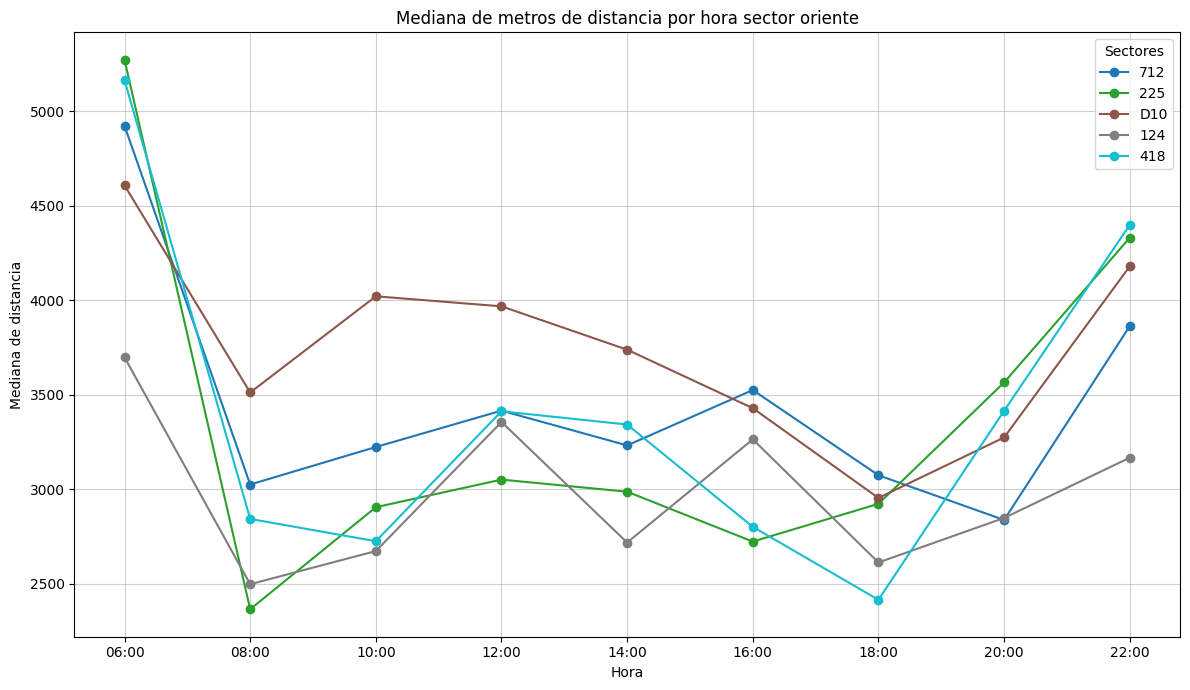

In [27]:
# GRAFICAMOS PARA SECTOR ORIENTE
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(meters_recorrido_oriente.columns):
    plt.plot(meters_recorrido_oriente.index,
            meters_recorrido_oriente[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(meters_recorrido_oriente.columns) - 1)))

plt.title("Mediana de metros de distancia por hora sector oriente")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

### ANÁLISIS PARCIAL METRO
Dado que ya tenemos cierta información que nos puede ser de bastante utilidad en cuanto a las micros, veamos ahora qué pasa con el metro y la situación de estaciones no operativas:

In [28]:
metro_no_operativo = metro_data[metro_data['status_code'] != 0]
metro_no_operativo.head(10)

,line_id,station_id,name,status_code,status_description,date,Hora_minuto
2981,L5,parque-bustamante,Parque Bustamante,1,Estación Temporalmente Cerrada,2025-10-13 20:30:03.573082,20:30
2982,L5,santa-isabel,Santa Isabel,1,Estación Temporalmente Cerrada,2025-10-13 20:30:03.573083,20:30
2983,L5,irarrazaval,Irarrázaval,1,Estación Temporalmente Cerrada,2025-10-13 20:30:03.573084,20:30
3124,L5,parque-bustamante,Parque Bustamante,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974478,21:30
3125,L5,santa-isabel,Santa Isabel,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974479,21:30
3126,L5,irarrazaval,Irarrázaval,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974480,21:30
3127,L5,nuble,Ñuble,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974482,21:30
3128,L5,rodrigo-de-araya,Rodrigo de Araya,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974483,21:30
3129,L5,carlos-valdovinos,Carlos Valdovinos,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974484,21:30
3130,L5,camino-agricola,Camino Agrícola,1,Estación Temporalmente Cerrada,2025-10-13 21:30:03.974487,21:30


In [29]:
# METROS NO OPERATIVOS LINEA 1
no_opera_l1 = metro_no_operativo[metro_no_operativo['line_id'] == 'L1']
no_opera_l1.head(10)
print(f'De la l1, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l1)} veces')


De la l1, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 3 veces


In [30]:
no_opera_l5 = metro_no_operativo[metro_no_operativo['line_id'] == 'L5']
no_opera_l5.head(10)
print(f'De la l5, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l5)} veces')


De la l5, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 27 veces


In [31]:
no_opera_l3 = metro_no_operativo[metro_no_operativo['line_id'] == 'L3']
print(f'De la l3, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l3)} veces')


De la l3, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [32]:
no_opera_l4 = metro_no_operativo[metro_no_operativo['line_id'] == 'L4']
print(f'De la l4, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l4)} veces')


De la l4, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [33]:
no_opera_l2 = metro_no_operativo[metro_no_operativo['line_id'] == 'L2']
print(f'De la l2, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l2)} veces')


De la l2, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


In [34]:
no_opera_l6 = metro_no_operativo[metro_no_operativo['line_id'] == 'L6']
print(f'De la l6, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas {len(no_opera_l6)} veces')


De la l6, durante el tiempo de extracción y recolección de datos desde el 12-10, el sistema no estuvo operativo en distintas horas 0 veces


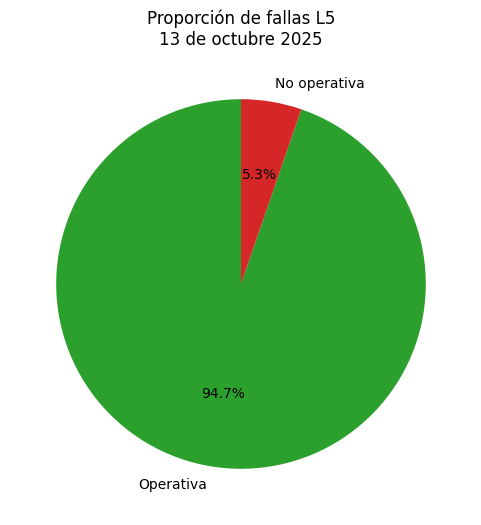

In [35]:
l5_df = metro_data[metro_data['line_id'] == 'L5']
# Filtramos solo registros del 13 de octubre, día que falló línea 5 y dejó líneas no operativas
df_13oct = l5_df[l5_df['date'].str.startswith('2025-10-13')]
total = len(df_13oct)
no_op = len(df_13oct[df_13oct['status_code'] != 0])
op = total - no_op

valores = [op, no_op]
etiquetas = ['Operativa', 'No operativa']
colors = ['#2ca02c', '#d62728'] 
plt.figure(figsize=(6,6))
plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proporción de fallas L5\n13 de octubre 2025')
plt.show()

## ANOTACIONES 
A partir del análisis de datos parcial, es necesario aclarar ciertos puntos:
* En primer lugar, aquella información extraída de las micros para el análisis se hizo sin considerar si era día laboral (lunes-viernes) o fin de semana, es algo en lo que se ahondará.
* A su vez, el análisis realizado está por ahora (con respecto a las micros) separado por sectores. Esto facilitará responder nuestras preguntas, pero de todas formas se hará al archivo unificado de micros
* Por último, en el archivo de metros es posible ver que hubo pocas veces problemas que detuvieran el servicio de transporte en ciertas estaciones. Ahora, al llevar poco más de una semana recolectando los datos, a esta altura no es posible poder concluir con base en ello el funcionamiento del metro; lo que sí, esta semana fue bastante bueno, fallando únicamente un poco en la L5 (y poquísimo en la L1).

Se seguirán recolectando datos (hasta ahora indefidamente) para un mejor análisis (según días de la semana, para tener más datos de fallas o no fallas del metro, etc)